# Exploratory Data Analysis:

---

In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
data = pd.read_csv("customer_churn_knn.csv")

In [3]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 1220
Number of columns: 17


In [4]:
print(f"Missing Values(%):\n{((data.isna().sum() / len(data)).round(3) * 100).sort_values(ascending=False)}")

Missing Values(%):
TotalSpend            4.2
MonthlyCharges        4.0
SatisfactionScore     3.9
DaysSinceLastLogin    3.9
CustomerID            0.0
ContractType          0.0
Churn                 0.0
AutoPayment           0.0
HasFamilyPlan         0.0
InternetPlan          0.0
PaymentDelayDays      0.0
NumberOfDevices       0.0
Age                   0.0
AvgWatchHours         0.0
SupportCalls          0.0
TenureMonths          0.0
InternalReference     0.0
dtype: float64


In [5]:
print(f"Duplicated Values: {data.duplicated().sum()}")

Duplicated Values: 0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          1220 non-null   int64  
 1   Age                 1220 non-null   int64  
 2   TenureMonths        1220 non-null   int64  
 3   MonthlyCharges      1171 non-null   float64
 4   TotalSpend          1169 non-null   float64
 5   SupportCalls        1220 non-null   int64  
 6   AvgWatchHours       1220 non-null   float64
 7   DaysSinceLastLogin  1172 non-null   float64
 8   PaymentDelayDays    1220 non-null   float64
 9   NumberOfDevices     1220 non-null   int64  
 10  ContractType        1220 non-null   object 
 11  InternetPlan        1220 non-null   object 
 12  HasFamilyPlan       1220 non-null   object 
 13  AutoPayment         1220 non-null   object 
 14  SatisfactionScore   1172 non-null   float64
 15  Churn               1220 non-null   int64  
 16  Intern

In [7]:
data.describe()

,CustomerID,Age,TenureMonths,MonthlyCharges,TotalSpend,SupportCalls,AvgWatchHours,DaysSinceLastLogin,PaymentDelayDays,NumberOfDevices,SatisfactionScore,Churn,InternalReference
count,1220.000000,1220.000000,1220.000000,1171.000000,1169.000000,1220.000000,1220.000000,1172.000000,1220.000000,1220.000000,1172.000000,1220.000000,1220.000000
mean,50599.725410,43.579508,31.176230,1796.155047,57746.989940,2.992623,12.156139,8.089317,3.066295,2.937705,5.449659,0.046721,558890.735246
std,346.928074,15.047785,17.093506,674.338789,45648.374961,1.661447,5.099718,7.983998,3.137254,1.410515,2.812080,0.211128,263229.462551
min,50001.000000,18.000000,1.000000,500.000000,-21305.020000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,102469.000000
25%,50299.750000,31.000000,17.000000,1304.350000,25517.040000,2.000000,8.717500,2.357500,0.840000,2.000000,3.000000,0.000000,327311.750000
50%,50599.500000,44.000000,32.000000,1805.570000,50054.220000,3.000000,12.000000,5.650000,2.035000,3.000000,5.000000,0.000000,560894.000000
75%,50898.250000,56.000000,46.000000,2243.210000,84087.410000,4.000000,15.727500,11.465000,4.240000,4.000000,8.000000,0.000000,791663.500000
max,51200.000000,69.000000,60.000000,3856.430000,482174.310000,12.000000,28.890000,60.000000,20.290000,5.000000,10.000000,1.000000,999980.000000


In [8]:
data.sample(10)

,CustomerID,Age,TenureMonths,MonthlyCharges,TotalSpend,SupportCalls,AvgWatchHours,DaysSinceLastLogin,PaymentDelayDays,NumberOfDevices,ContractType,InternetPlan,HasFamilyPlan,AutoPayment,SatisfactionScore,Churn,InternalReference
330,50333,58,4,1484.01,18827.02,2,4.34,8.88,2.03,4,TwoYear,Basic,No,Yes,6.0,0,102469
638,50194,18,18,1856.89,35635.06,2,11.95,6.28,2.38,3,TwoYear,Basic,No,Yes,5.0,0,427940
463,50030,42,24,2560.11,49968.43,3,15.24,11.49,7.56,1,Monthly,Standard,No,No,4.0,0,304999
343,50300,54,34,1195.97,52943.48,4,9.98,3.53,1.60,2,Monthly,Basic,No,Yes,1.0,0,552822
443,51164,59,55,1822.80,101841.43,4,11.41,13.46,2.47,3,Monthly,Premium,Yes,No,1.0,0,510223
416,51043,62,8,2176.64,7360.63,6,4.62,NaN,1.74,3,Monthly,Basic,No,Yes,6.0,0,519040
132,50287,59,11,1525.90,3628.12,3,6.11,3.96,1.36,2,Monthly,Standard,No,Yes,10.0,0,262602
904,50323,42,40,1639.71,63081.03,3,13.71,8.21,6.85,4,Monthly,Basic,No,Yes,8.0,0,476816
929,50017,20,2,1571.18,-4038.74,1,15.49,NaN,0.20,1,Monthly,Premium,Yes,Yes,3.0,0,814819
869,50506,20,8,1861.13,NaN,0,12.01,8.18,0.91,1,OneYear,Basic,No,Yes,6.0,0,205312


Churn
0    1163
1      57
Name: count, dtype: int64


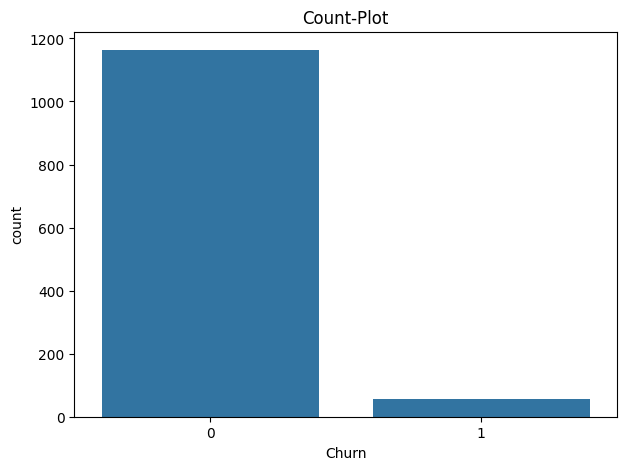

In [9]:
print(data['Churn'].value_counts())

fig = plt.figure(figsize=(7,5))

sns.countplot(data=data, x='Churn')
plt.title("Count-Plot")

plt.show()

In [10]:
print(f"Categorical Columns: {data.select_dtypes(include=['object']).columns.tolist()}")

Categorical Columns: ['ContractType', 'InternetPlan', 'HasFamilyPlan', 'AutoPayment']


In [11]:
pd.crosstab(index=data['ContractType'], columns=data['Churn'], normalize='index').round(3) * 100

Churn,0,1
ContractType,,
Monthly,94.5,5.5
OneYear,97.2,2.8
TwoYear,95.5,4.5


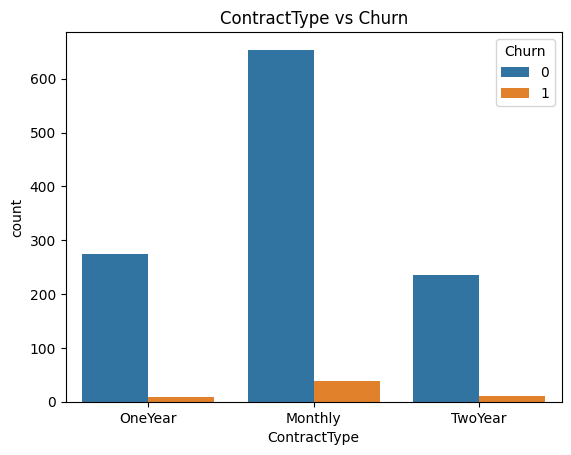

In [12]:
sns.countplot(data=data, x='ContractType', hue='Churn')
plt.title("ContractType vs Churn")

plt.show()

In [13]:
pd.crosstab(index=data['InternetPlan'], columns=data['Churn'], normalize='index').round(3) * 100

Churn,0,1
InternetPlan,,
Basic,94.8,5.2
Premium,93.5,6.5
Standard,96.5,3.5


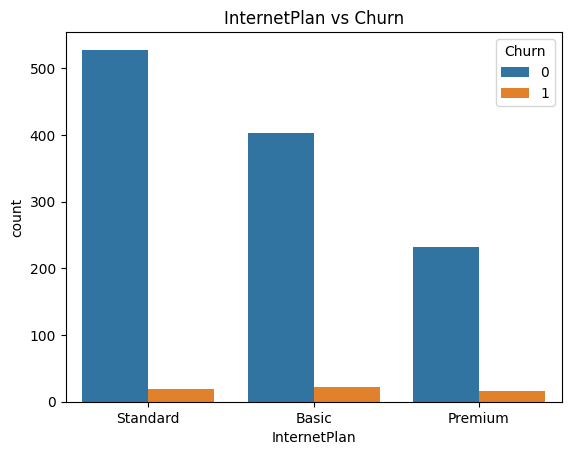

In [14]:
sns.countplot(data=data, x='InternetPlan', hue='Churn')
plt.title("InternetPlan vs Churn")

plt.show()

In [15]:
pd.crosstab(index=data['HasFamilyPlan'], columns=data['Churn'], normalize='index').round(3) * 100

Churn,0,1
HasFamilyPlan,,
No,95.0,5.0
Yes,96.0,4.0


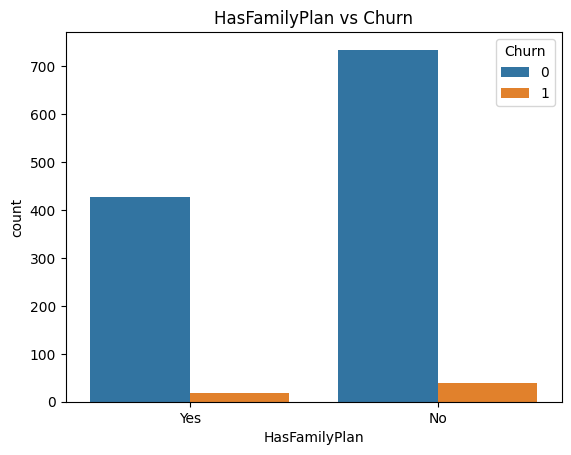

In [16]:
sns.countplot(data=data, x='HasFamilyPlan', hue='Churn')
plt.title("HasFamilyPlan vs Churn")

plt.show()

In [17]:
pd.crosstab(index=data['AutoPayment'], columns=data['Churn'], normalize='index').round(3) * 100

Churn,0,1
AutoPayment,,
No,95.0,5.0
Yes,95.5,4.5


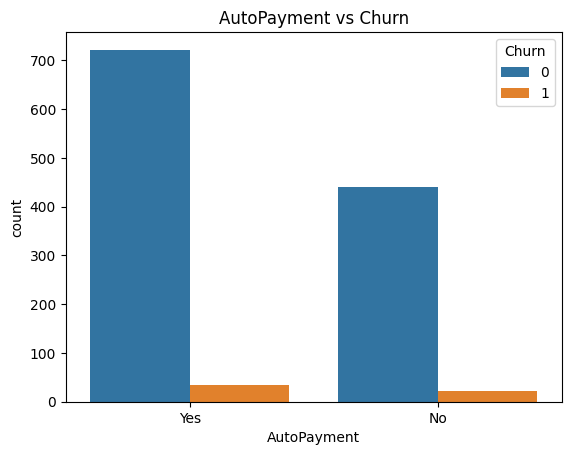

In [18]:
sns.countplot(data=data, x='AutoPayment', hue='Churn')
plt.title("AutoPayment vs Churn")

plt.show()

In [19]:
print(f"Categorical Columns: {data.select_dtypes(include=['float', 'int']).columns.tolist()}")

Categorical Columns: ['CustomerID', 'Age', 'TenureMonths', 'MonthlyCharges', 'TotalSpend', 'SupportCalls', 'AvgWatchHours', 'DaysSinceLastLogin', 'PaymentDelayDays', 'NumberOfDevices', 'SatisfactionScore', 'Churn', 'InternalReference']


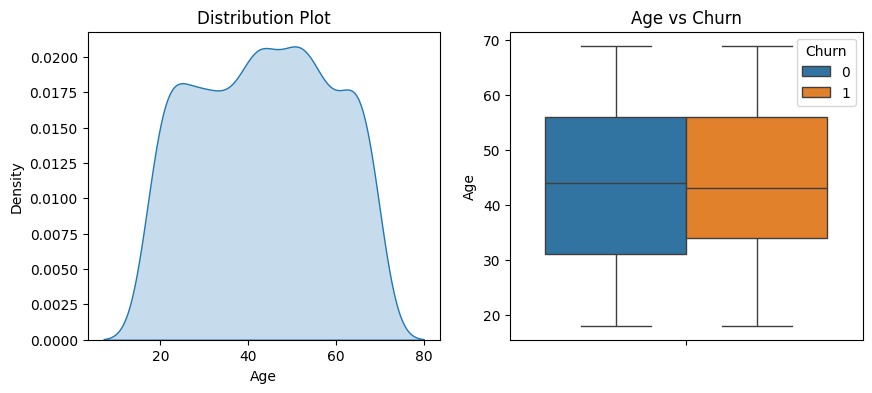

Skewness: -0.03


In [20]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

sns.kdeplot(data=data, x='Age', fill=True, ax=ax[0])
ax[0].set_title('Distribution Plot')

sns.boxplot(data=data, y='Age', hue='Churn', ax=ax[1])
ax[1].set_title('Age vs Churn')

plt.show()

print(f"Skewness: {(data['Age'].skew()).round(2)}")

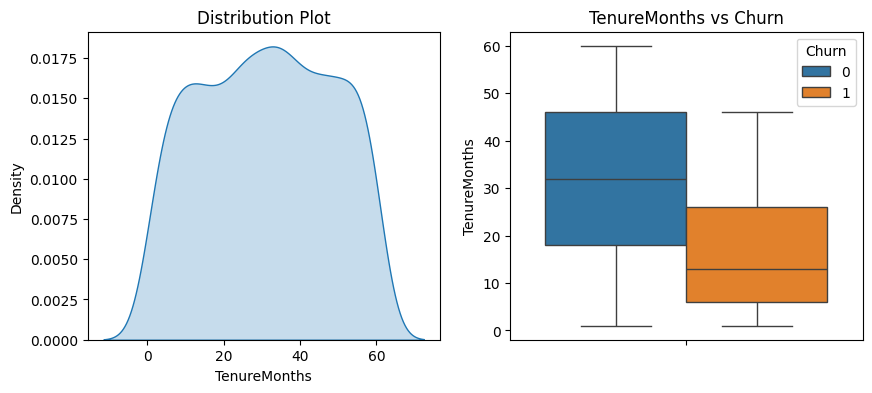

Skewness: -0.03


In [21]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

sns.kdeplot(data=data, x='TenureMonths', fill=True, ax=ax[0])
ax[0].set_title('Distribution Plot')

sns.boxplot(data=data, y='TenureMonths', hue='Churn', ax=ax[1])
ax[1].set_title('TenureMonths vs Churn')

plt.show()

print(f"Skewness: {(data['TenureMonths'].skew()).round(2)}")

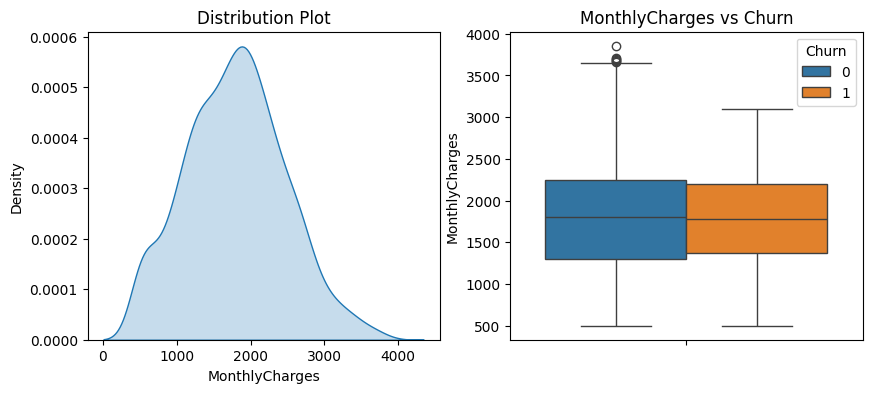

Skewness: 0.17


In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

sns.kdeplot(data=data, x='MonthlyCharges', fill=True, ax=ax[0])
ax[0].set_title('Distribution Plot')

sns.boxplot(data=data, y='MonthlyCharges', hue='Churn', ax=ax[1])
ax[1].set_title('MonthlyCharges vs Churn')

plt.show()

print(f"Skewness: {(data['MonthlyCharges'].skew()).round(2)}")

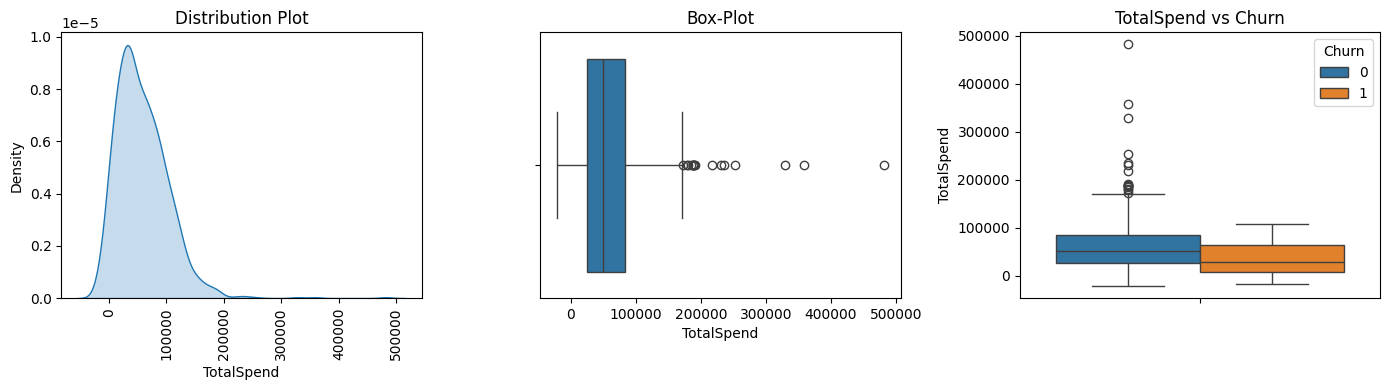

Skewness: 1.7


In [23]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14,4))

sns.kdeplot(data=data, x='TotalSpend', fill=True, ax=ax[0])
ax[0].set_title('Distribution Plot')
ax[0].tick_params(axis='x', rotation=90)

sns.boxplot(data=data, x='TotalSpend', ax=ax[1])
ax[1].set_title('Box-Plot')

sns.boxplot(data=data, y='TotalSpend', hue='Churn', ax=ax[2])
ax[2].set_title('TotalSpend vs Churn')

plt.tight_layout()
plt.show()

print(f"Skewness: {(data['TotalSpend'].skew()).round(2)}")

In [24]:
pd.crosstab(index=data['SupportCalls'], columns=data['Churn'], normalize='index').round(3) * 100

Churn,0,1
SupportCalls,,
0,98.1,1.9
1,97.2,2.8
2,95.5,4.5
3,97.3,2.7
4,91.5,8.5
5,93.5,6.5
6,96.6,3.4
7,88.9,11.1
8,100.0,0.0


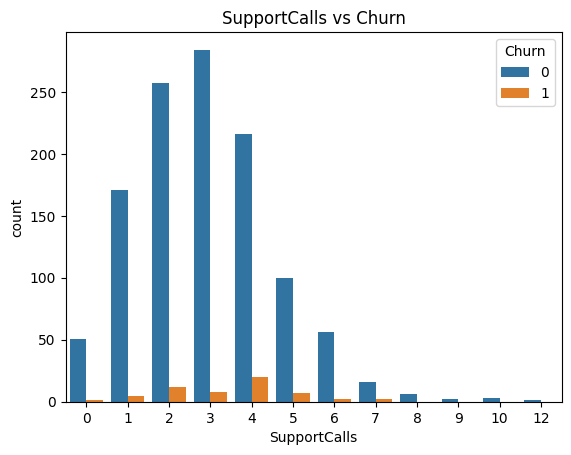

In [25]:
sns.countplot(data=data, x='SupportCalls', hue='Churn')
plt.title('SupportCalls vs Churn')

plt.show()

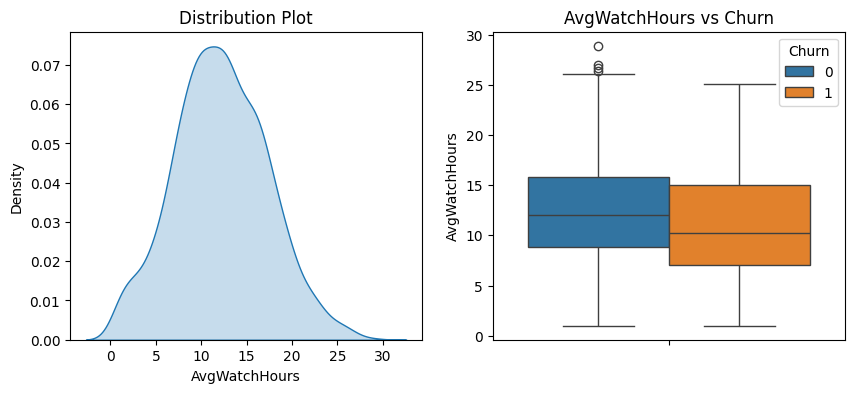

Skewness: 0.14


In [26]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

sns.kdeplot(data=data, x='AvgWatchHours', fill=True, ax=ax[0])
ax[0].set_title('Distribution Plot')

sns.boxplot(data=data, y='AvgWatchHours', hue='Churn', ax=ax[1])
ax[1].set_title('AvgWatchHours vs Churn')

plt.show()

print(f"Skewness: {(data['AvgWatchHours'].skew()).round(2)}")

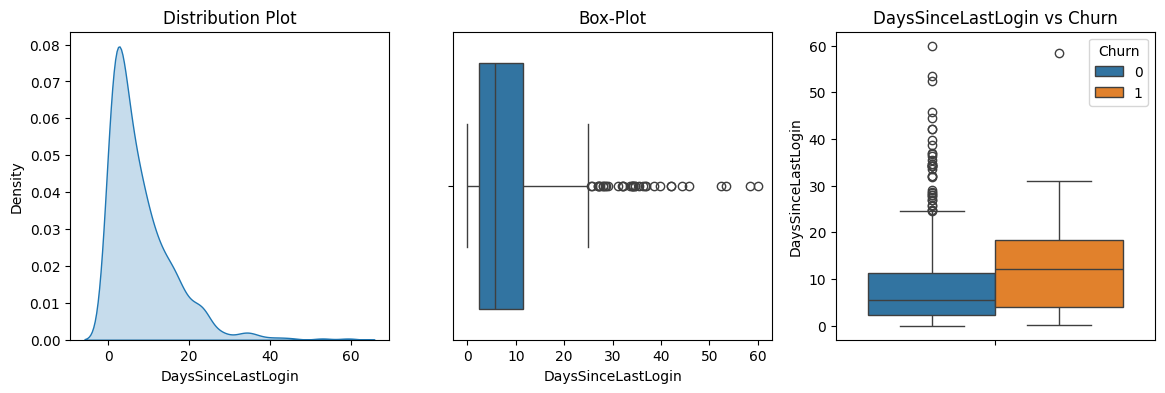

Skewness: 2.0


In [27]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14,4))

sns.kdeplot(data=data, x=data['DaysSinceLastLogin'], fill=True, ax=ax[0])
ax[0].set_title('Distribution Plot')

sns.boxplot(data=data, x=data['DaysSinceLastLogin'], ax=ax[1])
ax[1].set_title('Box-Plot')

sns.boxplot(data=data, y=data['DaysSinceLastLogin'], hue=data['Churn'], ax=ax[2])
ax[2].set_title('DaysSinceLastLogin vs Churn')

plt.show()

print(f"Skewness: {(data['DaysSinceLastLogin'].skew()).round(2)}")

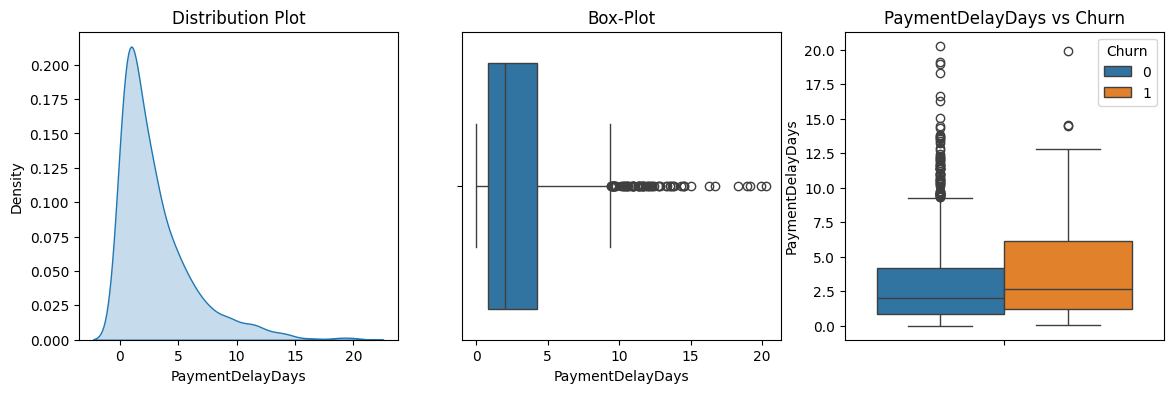

Skewness: 1.89


In [28]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14,4))

sns.kdeplot(data=data, x=data['PaymentDelayDays'], fill=True, ax=ax[0])
ax[0].set_title('Distribution Plot')

sns.boxplot(data=data, x=data['PaymentDelayDays'], ax=ax[1])
ax[1].set_title('Box-Plot')

sns.boxplot(data=data, y=data['PaymentDelayDays'], hue=data['Churn'], ax=ax[2])
ax[2].set_title('PaymentDelayDays vs Churn')

plt.show()

print(f"Skewness: {(data['PaymentDelayDays'].skew()).round(2)}")

In [29]:
pd.crosstab(index=data['NumberOfDevices'], columns=data['Churn'], normalize='index').round(3) * 100

Churn,0,1
NumberOfDevices,,
1,95.4,4.6
2,95.1,4.9
3,96.2,3.8
4,98.1,1.9
5,92.1,7.9


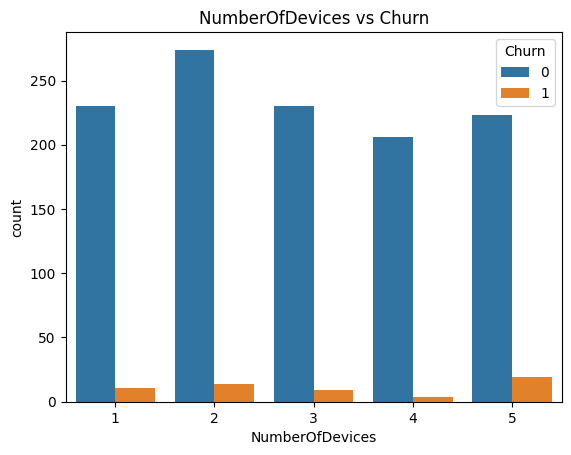

In [30]:
sns.countplot(data=data, x='NumberOfDevices', hue='Churn')
plt.title('NumberOfDevices vs Churn')

plt.show()

In [31]:
pd.crosstab(index=data['SatisfactionScore'], columns=data['Churn'], normalize='index').round(3) * 100

Churn,0,1
SatisfactionScore,,
1.0,86.5,13.5
2.0,97.6,2.4
3.0,89.1,10.9
4.0,95.0,5.0
5.0,96.9,3.1
6.0,95.4,4.6
7.0,97.2,2.8
8.0,98.4,1.6
9.0,98.9,1.1


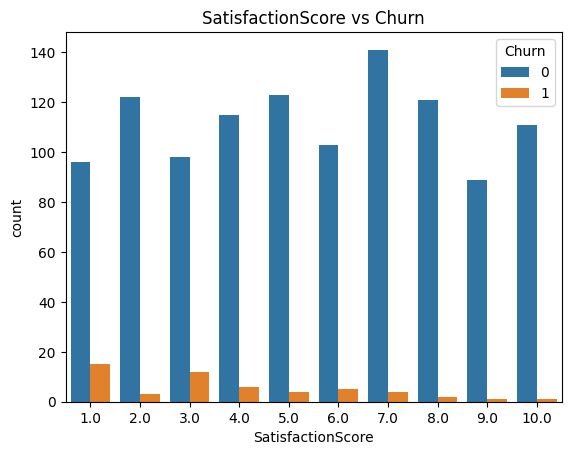

In [32]:
sns.countplot(data=data, x='SatisfactionScore', hue='Churn')
plt.title('SatisfactionScore vs Churn')

plt.show()

---

# Summary:

- **Target Feature:** *Churn*.

- **Input Features (Numerical):**
| Features | Feature Engineering |
| - | - |
| Age | Drop |
| MonthlyCharges | Drop |
| TotalSpend | SimpleImputer(median) |
| SatisfactionScore | SimpleImputer(most_frequent) |
| DaysSinceLastLogin | SimpleImputer(median) |

- **Input Features (Categorical):**
| Features | Feature Engineering |
| - | - |
| ContractType | One-Hot-Encoder |
| InternetPlan | Ordinal-Encoder |
| HasFamilyPlan | One-Hot-Enoder |
| AutoPayment | One-Hot-Enoder |

- Dataset is *Im-Balance*.

- There are no duplicated values.

- *CustomerID* and *InternalReference* are noisy features, hence *droped*.